# Lab 2: Linear Regression - SOLUTION
## MPS311/439 - Machine Learning
**Week 2 Lab Session**

This notebook contains complete solutions to all lab exercises.

## Part 0: Setup and Data Exploration

### Task 0.1: Import libraries and load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

### Task 0.2: Explore the data

In [2]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", diabetes.feature_names)
print("\nDescription:")
print(diabetes.DESCR[:500])

X shape: (442, 10)
y shape: (442,)

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Description:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative 


### Task 0.3: Visualize BMI vs disease progression

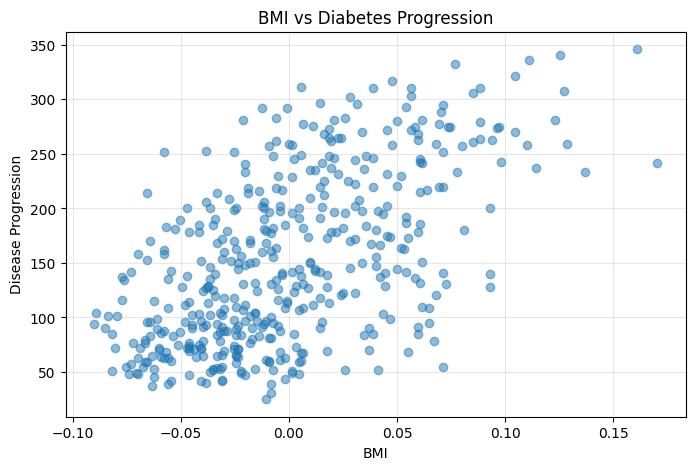

In [3]:
bmi = X[:, 2]

plt.figure(figsize=(8, 5))
plt.scatter(bmi, y, alpha=0.5)
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title('BMI vs Diabetes Progression')
plt.grid(True, alpha=0.3)
plt.show()

## Part 1: Your First Linear Regression Model

### Task 1.1: Prepare data

In [4]:
from sklearn.linear_model import LinearRegression

X_bmi = X[:, 2].reshape(-1, 1)

print("Original shape:", X[:, 2].shape)
print("Reshaped:", X_bmi.shape)

Original shape: (442,)
Reshaped: (442, 1)


### Task 1.2: Create and train model

In [5]:
model = LinearRegression()
model.fit(X_bmi, y)

print("Weight (w):", model.coef_[0])
print("Bias (b):", model.intercept_)

Weight (w): 949.4352603840385
Bias (b): 152.13348416289617


### Task 1.3: Make predictions

In [6]:
y_pred = model.predict(X_bmi)

print("First 3 predictions:", y_pred[:3])
print("First 3 actual:", y[:3])

First 3 predictions: [210.71003806 103.26219543 194.33703347]
First 3 actual: [151.  75. 141.]


### Task 1.4: Visualize fitted line

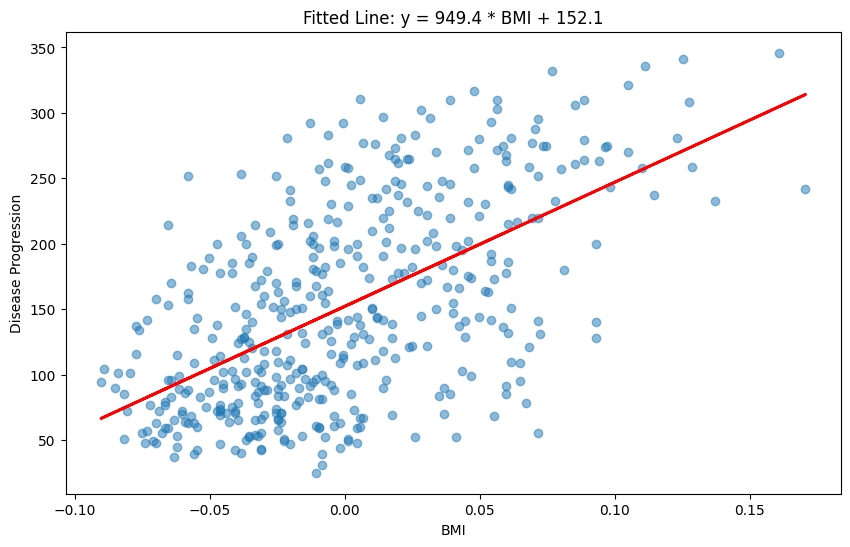

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(X_bmi, y, alpha=0.5)
plt.plot(X_bmi, y_pred, color='red', linewidth=2)
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title(f'Fitted Line: y = {model.coef_[0]:.1f} * BMI + {model.intercept_:.1f}')
plt.show()

## Part 2: Measuring Model Performance

### Task 2.1: Calculate MSE manually

In [8]:
residuals = y - y_pred
squared_residuals = residuals ** 2
mse_manual = np.mean(squared_residuals)

print("MSE (manual):", mse_manual)
print("RMSE:", np.sqrt(mse_manual))

MSE (manual): 3890.456585461273
RMSE: 62.37352471570989


### Task 2.2: Calculate metrics using sklearn

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

mse_sklearn = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE (sklearn):", mse_sklearn)
print("R² score:", r2)

MSE (sklearn): 3890.456585461273
R² score: 0.3439237602253802


### Task 2.3: Try blood pressure feature

In [10]:
X_bp = X[:, 3].reshape(-1, 1)

model_bp = LinearRegression()
model_bp.fit(X_bp, y)
y_pred_bp = model_bp.predict(X_bp)

mse_bp = mean_squared_error(y, y_pred_bp)
r2_bp = r2_score(y, y_pred_bp)

print("BMI       - MSE:", mse_sklearn, "R²:", r2)
print("Blood Press - MSE:", mse_bp, "R²:", r2_bp)

BMI       - MSE: 3890.456585461273 R²: 0.3439237602253802
Blood Press - MSE: 4774.113902368687 R²: 0.1949061431435003


## Part 3: Multiple Features & Train/Test Split

### Task 3.1: Split the data

In [11]:
from sklearn.model_selection import train_test_split

X_multi = X[:, [2, 3, 8]]

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape[0], "samples")
print("Test set:", X_test.shape[0], "samples")

Training set: 353 samples
Test set: 89 samples


### Task 3.2: Train model on training data

In [12]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print("Weights:", model_multi.coef_)
print("Bias:", model_multi.intercept_)

Weights: [650.63138341 283.8989004  491.98271159]
Bias: 151.67416300012866


### Task 3.3: Evaluate on both sets

In [13]:
y_train_pred = model_multi.predict(X_train)
y_test_pred = model_multi.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training - MSE:", train_mse, "R²:", train_r2)
print("Test     - MSE:", test_mse, "R²:", test_r2)

Training - MSE: 3140.6501518313194 R²: 0.4831394939699334
Test     - MSE: 2891.0372112919654 R²: 0.45433099153843415


### Task 3.4: Visualize predictions

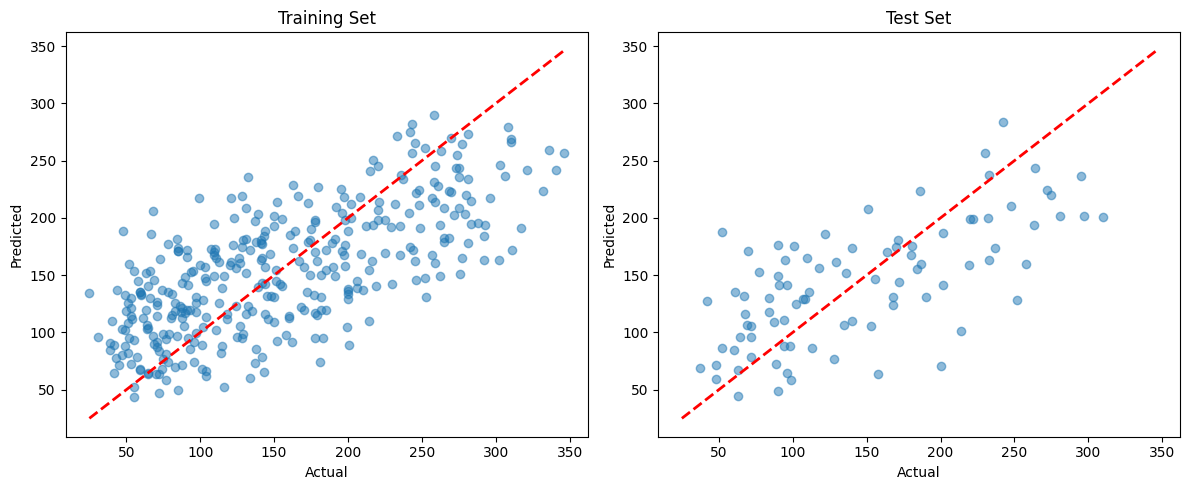

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Training Set')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Set')

plt.tight_layout()
plt.show()

## Part 4: Exploration & Mini-Challenge

### Challenge 4.1: Find best single feature

Best feature: s5
Test MSE: 3270.593898919842


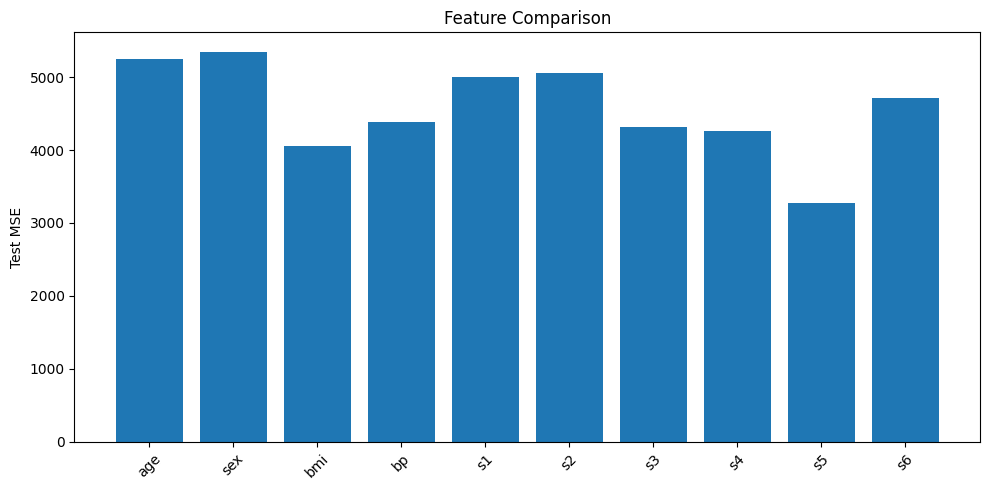

In [15]:
best_mse = float('inf')
best_feature_idx = None
mse_list = []

for i in range(10):
    X_feature = X[:, i].reshape(-1, 1)
    X_tr, X_te, y_tr, y_te = train_test_split(X_feature, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    mse = mean_squared_error(y_te, y_pred)
    mse_list.append(mse)
    
    if mse < best_mse:
        best_mse = mse
        best_feature_idx = i

print("Best feature:", diabetes.feature_names[best_feature_idx])
print("Test MSE:", best_mse)

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(range(10), mse_list)
plt.xticks(range(10), diabetes.feature_names, rotation=45)
plt.ylabel('Test MSE')
plt.title('Feature Comparison')
plt.tight_layout()
plt.show()

### Challenge 4.2: Use all features

In [16]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

y_test_pred_all = model_all.predict(X_test_all)

mse_all = mean_squared_error(y_test_all, y_test_pred_all)
r2_all = r2_score(y_test_all, y_test_pred_all)

print("All features - MSE:", mse_all, "R²:", r2_all)
print("3 features   - MSE:", test_mse, "R²:", test_r2)
print("Best single  - MSE:", best_mse)

All features - MSE: 2900.19362849348 R²: 0.4526027629719197
3 features   - MSE: 2891.0372112919654 R²: 0.45433099153843415
Best single  - MSE: 3270.593898919842


## Part 5A: Normal Equation (MPS439)

### Task 5A.1: Implement normal equation

In [17]:
def normal_equation(X, y):
    n = X.shape[0]
    X_with_bias = np.column_stack([np.ones(n), X])
    
    XtX = X_with_bias.T @ X_with_bias
    XtX_inv = np.linalg.inv(XtX)
    Xty = X_with_bias.T @ y
    w = XtX_inv @ Xty
    
    return w

X_multi = X[:, [2, 3, 8]]
w_normal = normal_equation(X_multi, y)

print("Normal Equation:")
print("Bias:", w_normal[0])
print("Weights:", w_normal[1:])

model_compare = LinearRegression()
model_compare.fit(X_multi, y)

print("\nsklearn:")
print("Bias:", model_compare.intercept_)
print("Weights:", model_compare.coef_)

Normal Equation:
Bias: 152.13348416289602
Weights: [603.07835741 262.27200281 543.87120586]

sklearn:
Bias: 152.13348416289602
Weights: [603.07835741 262.27200281 543.87120586]


### Task 5A.2: Make predictions

In [18]:
def predict_normal(X, w):
    n = X.shape[0]
    X_with_bias = np.column_stack([np.ones(n), X])
    return X_with_bias @ w

y_pred_normal = predict_normal(X_multi, w_normal)
y_pred_sklearn = model_compare.predict(X_multi)

mse_normal = np.mean((y - y_pred_normal)**2)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

print("MSE (Normal Eq):", mse_normal)
print("MSE (sklearn):", mse_sklearn)
print("Match:", np.allclose(mse_normal, mse_sklearn))

MSE (Normal Eq): 3083.0513432257203
MSE (sklearn): 3083.0513432257203
Match: True


## Part 5B: Gradient Descent (MPS439)

### Task 5B.1: Implement gradient descent

In [19]:
def gradient_descent(X, y, learning_rate=0.5, iterations=1000):
    n, p = X.shape
    X_with_bias = np.column_stack([np.ones(n), X])
    w = np.zeros(p + 1)
    losses = []
    
    for i in range(iterations):
        y_pred = X_with_bias @ w
        loss = np.mean((y - y_pred)**2)
        losses.append(loss)
        
        gradient = (2/n) * X_with_bias.T @ (y_pred - y)
        w = w - learning_rate * gradient
        
        if (i + 1) % 200 == 0:
            print(f"Iteration {i+1}: Loss = {loss:.2f}")
    
    return w, losses

w_gd, losses = gradient_descent(X_multi, y, learning_rate=0.5, iterations=1000)

print("\nGradient Descent:")
print("Bias:", w_gd[0])
print("Weights:", w_gd[1:])

Iteration 200: Loss = 3663.05
Iteration 400: Loss = 3211.68
Iteration 600: Loss = 3117.74
Iteration 800: Loss = 3095.44
Iteration 1000: Loss = 3088.71

Gradient Descent:
Bias: 152.13348416289602
Weights: [563.91514253 303.02695342 521.64590326]


### Task 5B.2: Visualize convergence

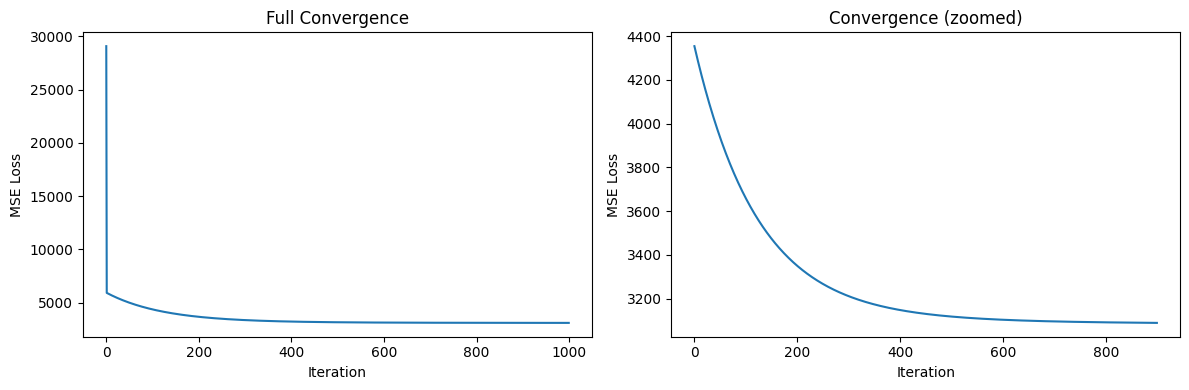

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Full Convergence')

plt.subplot(1, 2, 2)
plt.plot(losses[100:])
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Convergence (zoomed)')

plt.tight_layout()
plt.show()

### Task 5B.3: Compare all methods

In [21]:
y_pred_gd = predict_normal(X_multi, w_gd)
mse_gd = np.mean((y - y_pred_gd)**2)

print("sklearn         - MSE:", mse_sklearn)
print("Normal Equation - MSE:", mse_normal)
print("Gradient Descent - MSE:", mse_gd)

sklearn         - MSE: 3083.0513432257203
Normal Equation - MSE: 3083.0513432257203
Gradient Descent - MSE: 3088.6855544034493


### Task 5B.4: Experiment with learning rates

Iteration 200: Loss = 5847.08
Iteration 400: Loss = 5751.83
Iteration 200: Loss = 5146.80
Iteration 400: Loss = 4579.13
Iteration 200: Loss = 3663.05
Iteration 400: Loss = 3211.68
Iteration 200: Loss = 26356.47
Iteration 400: Loss = 26240.03


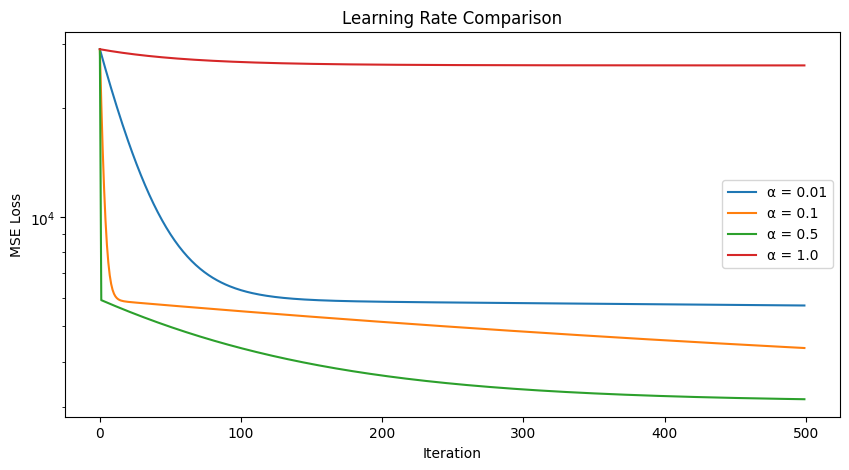

In [22]:
learning_rates = [0.01, 0.1, 0.5, 1.0]

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    _, losses_lr = gradient_descent(X_multi, y, learning_rate=lr, iterations=500)
    plt.plot(losses_lr, label=f'α = {lr}')

plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Learning Rate Comparison')
plt.legend()
plt.yscale('log')
plt.show()

## Summary

This notebook demonstrated:
- Loading and exploring data
- Building linear regression models
- Evaluating with MSE and R²
- Train/test splitting
- Comparing different features
- Implementing Normal Equation (MPS439)
- Implementing Gradient Descent (MPS439)

Key findings:
- Single features have limited predictive power (R² ≈ 0.03-0.05)
- Multiple features improve performance
- All three methods (sklearn, Normal Equation, Gradient Descent) give equivalent results
- Learning rate is crucial for gradient descent convergence